
Round Robin Scheduler (TQ = 3)
PID  AT  BT  CT  TAT  WT
 P1  10   4  31   21  17
 P2   6   9  34   28  19
 P3   4   9  30   26  17
 P4   6   9  37   31  22
 P5   2   4   9    7   3
Average Waiting Time:    15.60
Average Turnaround Time: 22.60


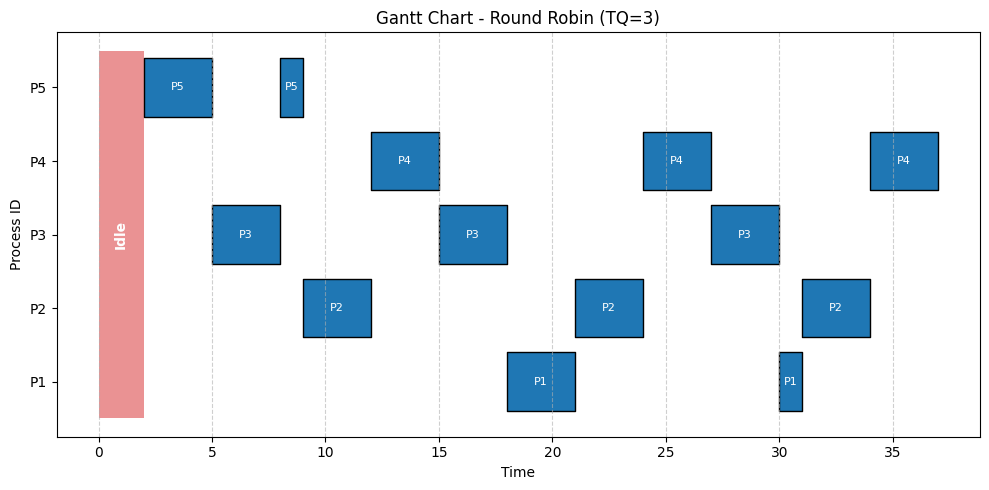

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

n = int(input("Enter number of processes: "))
tq = int(input("Enter Time Quantum: "))
processes = []

for i in range(n):
    bt = random.randint(1, 10)
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': bt,
        'RBT': bt
    })

processes.sort(key=lambda x: x['AT']) 

current_time = 0
timeline = [] 
ready_queue = deque()
completed_count = 0
arrived_indices = [False] * n 

if processes[0]['AT'] > current_time:
    timeline.append(('Idle', current_time, processes[0]['AT']))
    current_time = processes[0]['AT']

for i in range(n):
    if processes[i]['AT'] <= current_time and not arrived_indices[i]:
        ready_queue.append(i)
        arrived_indices[i] = True

while completed_count < n:
    if not ready_queue:
        next_arrival = min([p['AT'] for i, p in enumerate(processes) if not arrived_indices[i]])
        timeline.append(('Idle', current_time, next_arrival))
        current_time = next_arrival
        
        for i in range(n):
            if processes[i]['AT'] <= current_time and not arrived_indices[i]:
                ready_queue.append(i)
                arrived_indices[i] = True

    current_idx = ready_queue.popleft()
    p = processes[current_idx]
    
    start_time = current_time
    exec_time = min(tq, p['RBT'])
    
    p['RBT'] -= exec_time
    current_time += exec_time
    
    timeline.append((p['PID'], start_time, current_time))
    
    for i in range(n):
        if processes[i]['AT'] <= current_time and not arrived_indices[i]:
            ready_queue.append(i)
            arrived_indices[i] = True
            
    if p['RBT'] > 0:
        ready_queue.append(current_idx)
    else:
        p['CT'] = current_time
        p['TAT'] = p['CT'] - p['AT']
        p['WT'] = p['TAT'] - p['BT']
        completed_count += 1

df = pd.DataFrame(processes).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print(f"\nRound Robin Scheduler (TQ = {tq})")
print(df[['PID', 'AT', 'BT', 'CT', 'TAT', 'WT']].to_string(index=False))
print(f"Average Waiting Time:    {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))

unique_pids = sorted(df['PID'].unique())
y_positions = {pid: i for i, pid in enumerate(unique_pids)}
mid_y = len(unique_pids) / 2 - 0.5

for label, start, end in timeline:
    duration = end - start
    if duration == 0: continue
        
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)), facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, mid_y, "Idle", ha='center', va='center', color='white', fontweight='bold', rotation=90)
    else:
        y = y_positions[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        if duration >= 1: 
            ax.text(start + duration/2, y, label, ha='center', va='center', color='white', fontsize=8)

ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Process ID')
ax.set_title(f'Gantt Chart - Round Robin (TQ={tq})')
ax.grid(True, axis='x', linestyle = '--', alpha=0.6)

plt.tight_layout()
plt.show()



Round Robin Scheduler (TQ = 4)
PID  AT  BT  CT  TAT  WT
 P1   5   8  25   20  12
 P2   5   8  29   24  16
 P3   3   2   8    5   3
 P4  10   3  21   11   8
 P5   2   4   6    4   0
 P6   5   2  18   13  11
Average Waiting Time:    8.33
Average Turnaround Time: 12.83


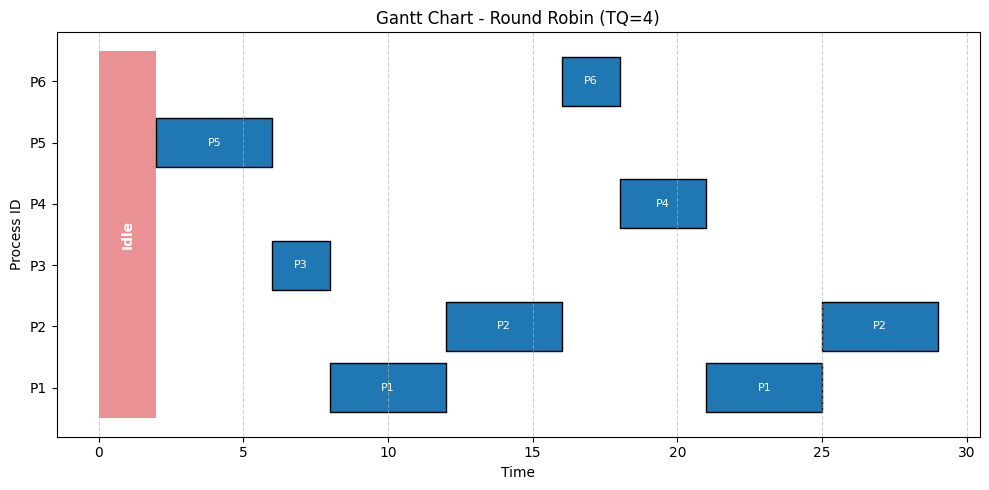

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

n = int(input("Enter number of processes: "))
tq = int(input("Enter Time Quantum: "))
processes = []

for i in range(n):
    bt = random.randint(1, 10)
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': bt,
        'RBT': bt
    })

processes.sort(key=lambda x: x['AT']) 

current_time = 0
timeline = [] 
ready_queue = deque()
completed_count = 0
arrived_indices = [False] * n 

if processes[0]['AT'] > current_time:
    timeline.append(('Idle', current_time, processes[0]['AT']))
    current_time = processes[0]['AT']

for i in range(n):
    if processes[i]['AT'] <= current_time and not arrived_indices[i]:
        ready_queue.append(i)
        arrived_indices[i] = True

while completed_count < n:
    
    if not ready_queue:
        next_arrival = min([p['AT'] for i, p in enumerate(processes) if not arrived_indices[i]])
        timeline.append(('Idle', current_time, next_arrival))
        current_time = next_arrival
        
        for i in range(n):
            if processes[i]['AT'] <= current_time and not arrived_indices[i]:
                ready_queue.append(i)
                arrived_indices[i] = True

    current_idx = ready_queue.popleft()
    p = processes[current_idx]
    
    start_time = current_time
    exec_time = min(tq, p['RBT'])
    
    p['RBT'] -= exec_time
    current_time += exec_time
    
    timeline.append((p['PID'], start_time, current_time))
    
    for i in range(n):
        if processes[i]['AT'] <= current_time and not arrived_indices[i]:
            ready_queue.append(i)
            arrived_indices[i] = True
            
    if p['RBT'] > 0:
        ready_queue.append(current_idx)
    else:
        p['CT'] = current_time
        p['TAT'] = p['CT'] - p['AT']
        p['WT'] = p['TAT'] - p['BT']
        completed_count += 1

df = pd.DataFrame(processes).sort_values(by='PID')

avg_wt = df['WT'].mean()
avg_tat = df['TAT'].mean()

print(f"\nRound Robin Scheduler (TQ = {tq})")
print(df[['PID', 'AT', 'BT', 'CT', 'TAT', 'WT']].to_string(index=False))
print(f"Average Waiting Time:    {avg_wt:.2f}")
print(f"Average Turnaround Time: {avg_tat:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))

unique_pids = sorted(df['PID'].unique())
y_positions = {pid: i for i, pid in enumerate(unique_pids)}
mid_y = len(unique_pids) / 2 - 0.5

for label, start, end in timeline:
    duration = end - start
    if duration == 0: continue
        
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)), facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, mid_y, "Idle", ha='center', va='center', color='white', fontweight='bold', rotation=90)
    else:
        y = y_positions[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        if duration >= 1: 
            ax.text(start + duration/2, y, label, ha='center', va='center', color='white', fontsize=8)

ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Process ID')
ax.set_title(f'Gantt Chart - Round Robin (TQ={tq})')
ax.grid(True, axis='x', linestyle = '--', alpha=0.6)

plt.tight_layout()
plt.show()
